### Familiarize with dataset

In [1]:
import pandas as pd
from features import *

data = pd.read_csv('train.csv')
data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [2]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


In [3]:
data.isna().sum() / len(data) * 100

PassengerId     0.000000
HomePlanet      2.312205
CryoSleep       2.496261
Cabin           2.289198
Destination     2.093639
Age             2.059128
VIP             2.335212
RoomService     2.082135
FoodCourt       2.105142
ShoppingMall    2.392730
Spa             2.105142
VRDeck          2.162660
Name            2.300702
Transported     0.000000
dtype: float64

### Missing Values:

 - `CryoSleep` If passenger spend some amount of money then `True` otherwise `False`
 - `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck` imputed with median values when passenger wasn't in `CryoSleep`
 - `VIP` imputed with most frequent value (SimpleImputer)
 - `Age` imputed with median (SimpleImputer)
 - `Destination` imputed with most frequent value (SimpleImputer)
 - `Name` the entire column was dropped
 - `HomePlanet` imputed with most frequent value (SimpleImputer)
 - `Cabin` divided into three independent columns (Deck, Num, Side) and then the `Cabin` column was dropped
 - `Deck` imputed with most frequent value (SimpleImputer)
 - `Num` the entire column was dropped
 - `Side` imputed with most frequent value (SimpleImputer)
 - `PassengerID` group number was extracted into new column `Group`

In [4]:
cryosleep(data)
money_columns(data)
cabin(data)
passenger(data)
vip(data)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,MoneySpend,Deck,Num,Side,Group
0,0001_01,Europa,0,B/0/P,TRAPPIST-1e,39.0,0.0,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,0.0,B,0,P,1
1,0002_01,Earth,0,F/0/S,TRAPPIST-1e,24.0,0.0,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,736.0,F,0,S,2
2,0003_01,Europa,0,A/0/S,TRAPPIST-1e,58.0,1.0,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,10383.0,A,0,S,3
3,0003_02,Europa,0,A/0/S,TRAPPIST-1e,33.0,0.0,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,5176.0,A,0,S,3
4,0004_01,Earth,0,F/1/S,TRAPPIST-1e,16.0,0.0,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,1091.0,F,1,S,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,0,A/98/P,55 Cancri e,41.0,1.0,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False,8536.0,A,98,P,9276
8689,9278_01,Earth,1,G/1499/S,PSO J318.5-22,18.0,0.0,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False,0.0,G,1499,S,9278
8690,9279_01,Earth,0,G/1500/S,TRAPPIST-1e,26.0,0.0,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True,1873.0,G,1500,S,9279
8691,9280_01,Europa,0,E/608/S,55 Cancri e,32.0,0.0,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False,4637.0,E,608,S,9280


In [5]:
data.isna().sum() / len(data) * 100

PassengerId     0.000000
HomePlanet      2.312205
CryoSleep       0.000000
Cabin           2.289198
Destination     2.093639
Age             2.059128
VIP             2.335212
RoomService     0.000000
FoodCourt       0.000000
ShoppingMall    0.000000
Spa             0.000000
VRDeck          0.000000
Name            2.300702
Transported     0.000000
MoneySpend      0.000000
Deck            2.289198
Num             2.289198
Side            2.289198
Group           0.000000
dtype: float64

In [6]:
data['VIP'].value_counts()

VIP
0.0    8291
1.0     199
Name: count, dtype: int64

<Axes: >

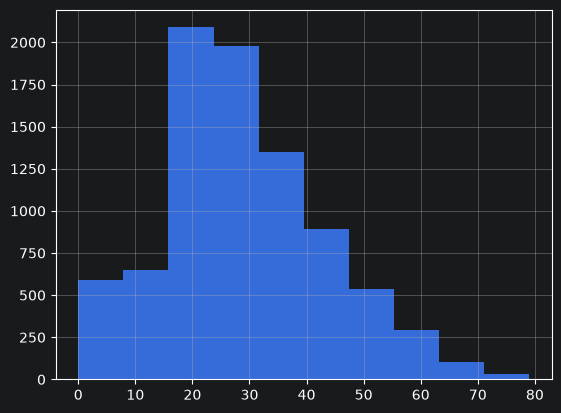

In [7]:
data['Age'].hist()

In [8]:
data['Destination'].value_counts()

Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
Name: count, dtype: int64

In [9]:
len(data['Name'].unique())

8474

In [10]:
data['HomePlanet'].value_counts()

HomePlanet
Earth     4602
Europa    2131
Mars      1759
Name: count, dtype: int64

In [11]:
data['Deck'].value_counts()

Deck
F    2794
G    2559
E     876
B     779
C     747
D     478
A     256
T       5
Name: count, dtype: int64

In [12]:
data['Side'].value_counts()

Side
S    4288
P    4206
Name: count, dtype: int64

In [13]:
data['Num'].value_counts()

Num
82      28
19      22
86      22
56      21
97      21
        ..
1886     1
1891     1
1892     1
1893     1
1894     1
Name: count, Length: 1817, dtype: int64